Lab 22.3 – Stratified Sampling
Goal:

Build an imbalanced binary dataset

Compare KFold vs StratifiedKFold class distributions per fold

Train a classifier under both CV schemes and compare metric stability

(Optional) Add class weights and resampling to see effects


In [1]:
# pip install scikit-learn matplotlib seaborn numpy pandas
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Create a clearly imbalanced dataset

In [2]:
X, y = make_classification(
    n_samples=6000, n_features=20, n_informative=6, n_redundant=4, n_repeated=0,
    n_clusters_per_class=2, weights=[0.94, 0.06], flip_y=0.01, class_sep=1.0, random_state=0
)
np.bincount(y), y.mean()  # ~6% positives

(array([5612,  388]), np.float64(0.06466666666666666))

2) How folds distribute classes: KFold vs StratifiedKFold

In [3]:
def fold_label_stats(splitter, y, name):
    rows = []
    for i, (_, te) in enumerate(splitter.split(np.zeros_like(y), y)):
        pos = y[te].sum(); n = len(te)
        rows.append((i, n, int(pos), pos/n))
    df = pd.DataFrame(rows, columns=['fold','n','pos','pos_rate'])
    df['scheme'] = name
    return df

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dist = pd.concat([
    fold_label_stats(kf,  y, 'KFold'),
    fold_label_stats(skf, y, 'StratifiedKFold')
], ignore_index=True)
dist

,fold,n,pos,pos_rate,scheme
0,0,1200,83,0.069167,KFold
1,1,1200,79,0.065833,KFold
2,2,1200,64,0.053333,KFold
3,3,1200,78,0.065000,KFold
4,4,1200,84,0.070000,KFold
5,0,1200,77,0.064167,StratifiedKFold
6,1,1200,77,0.064167,StratifiedKFold
7,2,1200,78,0.065000,StratifiedKFold
8,3,1200,78,0.065000,StratifiedKFold
9,4,1200,78,0.065000,StratifiedKFold


Plot: stratification keeps each fold’s positive rate close to global.

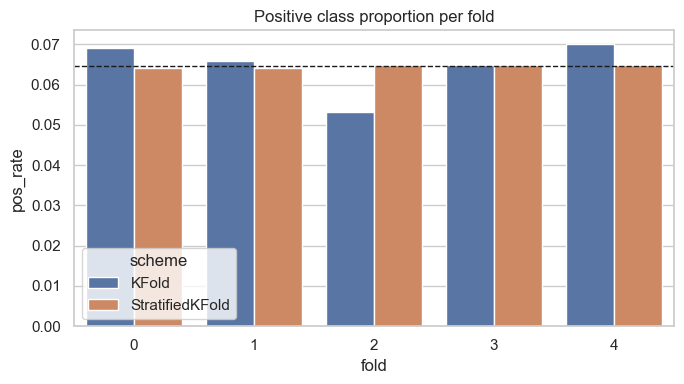

In [4]:
plt.figure(figsize=(7,4))
sns.barplot(data=dist, x='fold', y='pos_rate', hue='scheme')
plt.axhline(y.mean(), color='k', ls='--', lw=1, label='global rate')
plt.title('Positive class proportion per fold'); plt.ylabel('pos_rate'); plt.tight_layout(); plt.show()

3) Model & metrics
We’ll evaluate Accuracy, F1 (binary), Recall (pos), ROC‑AUC.

In [5]:
scoring = {
    'acc': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'roc': 'roc_auc'
}

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

4) 5‑fold CV with KFold vs StratifiedKFold

In [6]:
from sklearn.model_selection import cross_validate

cv_kf  = cross_validate(logreg, X, y, cv=kf,  scoring=scoring, n_jobs=-1, return_train_score=False)
cv_skf = cross_validate(logreg, X, y, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=False)

def summarize(cvres):
    return {m: (np.mean(cvres['test_'+m]), np.std(cvres['test_'+m])) for m in ['acc','f1','recall','roc']}

summary = pd.DataFrame({
    'metric': ['acc','f1','recall','roc'],
    'KFold_mean':   [summarize(cv_kf)[m][0]  for m in ['acc','f1','recall','roc']],
    'KFold_std':    [summarize(cv_kf)[m][1]  for m in ['acc','f1','recall','roc']],
    'Strat_mean':   [summarize(cv_skf)[m][0] for m in ['acc','f1','recall','roc']],
    'Strat_std':    [summarize(cv_skf)[m][1] for m in ['acc','f1','recall','roc']],
}).round(4)
summary

,metric,KFold_mean,KFold_std,Strat_mean,Strat_std
0,acc,0.9693,0.0044,0.9687,0.0037
1,f1,0.7012,0.0420,0.6956,0.0439
2,recall,0.5601,0.0464,0.5567,0.0506
3,roc,0.8980,0.0183,0.8967,0.0335


Expectation: StratifiedKFold yields more stable (lower std) and often better recall/F1 on the minority class.

5) (Optional) Add class_weight='balanced'

In [7]:
logreg_bal = make_pipeline(StandardScaler(),
                           LogisticRegression(max_iter=2000, class_weight='balanced'))
cv_skf_bal = cross_validate(logreg_bal, X, y, cv=skf, scoring=scoring, n_jobs=-1)

summary_bal = pd.DataFrame({
    'metric': ['acc','f1','recall','roc'],
    'Strat_no_wt_mean': [np.mean(cv_skf['test_'+m])     for m in ['acc','f1','recall','roc']],
    'Strat_bal_mean':   [np.mean(cv_skf_bal['test_'+m]) for m in ['acc','f1','recall','roc']],
}).round(4)
summary_bal

,metric,Strat_no_wt_mean,Strat_bal_mean
0,acc,0.9687,0.8578
1,f1,0.6956,0.4305
2,recall,0.5567,0.8270
3,roc,0.8967,0.8951


You should see higher recall (and often F1) with class weights, sometimes a small accuracy drop.

6) (Optional) Resampling inside CV (advanced)
If you have imblearn, compare RandomUnderSampler / SMOTE inside a pipeline.

In [10]:
# pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

pipe_smote = ImbPipeline([
    ('sc', StandardScaler()),
    ('sm', SMOTE(random_state=0)),
    ('lr', LogisticRegression(max_iter=2000))
])
cv_smote = cross_validate(pipe_smote, X, y, cv=skf, scoring=scoring, n_jobs=-1)
{m: np.mean(cv_smote['test_'+m]) for m in ['acc','f1','recall','roc']}

{'acc': np.float64(0.8748333333333334),
 'f1': np.float64(0.4558106805423619),
 'recall': np.float64(0.8062937062937063),
 'roc': np.float64(0.8952303584879143)}

7) Quick per‑fold variability visualization

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15176\1201404245.py:11: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


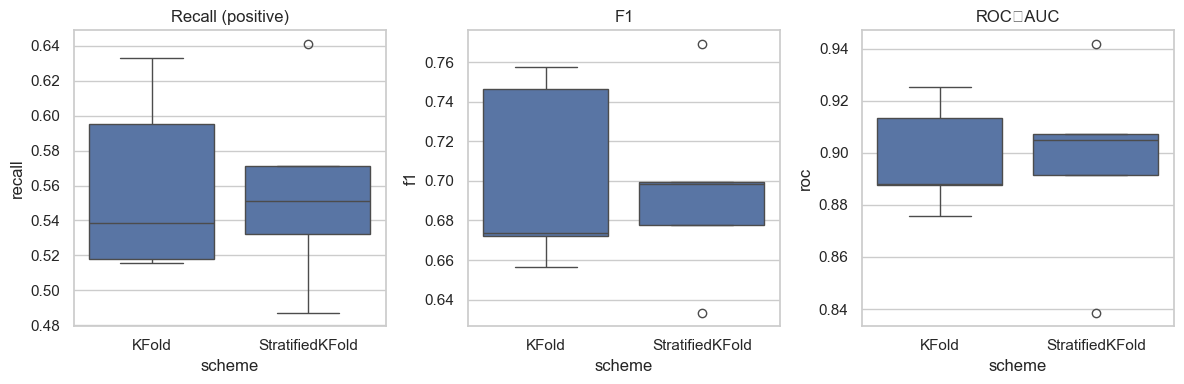

In [11]:
plot_df = []
for tag, res in [('KFold', cv_kf), ('StratifiedKFold', cv_skf)]:
    for i, (a, f1, r, roc) in enumerate(zip(res['test_acc'], res['test_f1'], res['test_recall'], res['test_roc'])):
        plot_df.append((tag, i, a, f1, r, roc))
plot_df = pd.DataFrame(plot_df, columns=['scheme','fold','acc','f1','recall','roc'])

fig, axes = plt.subplots(1,3, figsize=(12,4))
sns.boxplot(data=plot_df, x='scheme', y='recall', ax=axes[0]); axes[0].set_title('Recall (positive)')
sns.boxplot(data=plot_df, x='scheme', y='f1',     ax=axes[1]); axes[1].set_title('F1')
sns.boxplot(data=plot_df, x='scheme', y='roc',    ax=axes[2]); axes[2].set_title('ROC‑AUC')
plt.tight_layout(); plt.show()

Rarer minority: Regenerate data with weights=[0.98, 0.02]. Re‑run Sections 2–4. How much worse do KFold fold proportions get? How do metrics’ std change?

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# --- Section 1: Regenerate Data with [0.98, 0.02] weights ---
n_samples = 1000
weights = [0.98, 0.02]

X, y = make_classification(
    n_samples=n_samples,
    n_features=20,
    n_informative=2,
    n_redundant=10,
    n_clusters_per_class=1,
    weights=weights,
    flip_y=0,  # Reduce noise to isolate class imbalance effects
    random_state=42
)

print(f"Total Minority Samples: {sum(y)} out of {n_samples} ({sum(y)/n_samples:.2%})")

# --- Section 2 & 3: KFold Splitting and Proportion Analysis ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_stats = []
f1_scores = []
model = LogisticRegression(solver='liblinear')

print("\n--- KFold Analysis (5 Splits) ---")
for fold_idx, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Calculate minority proportion in this specific test fold
    minority_count = sum(y_test)
    total_count = len(y_test)
    prop = minority_count / total_count
    
    fold_stats.append(prop)
    
    # Train and Evaluate
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds)
    f1_scores.append(score)
    
    print(f"Fold {fold_idx+1}: Minority Count={minority_count}/{total_count} ({prop:.2%}) | F1 Score: {score:.4f}")

# --- Section 4: Aggregated Metrics ---
print("\n--- Results Summary ---")
print(f"Target Proportion: {weights[1]:.2%}")
print(f"Fold Proportions Range: {min(fold_stats):.2%} - {max(fold_stats):.2%}")
print(f"Fold Proportions Std Dev: {np.std(fold_stats):.4f}")
print(f"F1 Score Mean: {np.mean(f1_scores):.4f}")
print(f"F1 Score Std Dev: {np.std(f1_scores):.4f}")


Total Minority Samples: 20 out of 1000 (2.00%)

--- KFold Analysis (5 Splits) ---
Fold 1: Minority Count=2/200 (1.00%) | F1 Score: 1.0000
Fold 2: Minority Count=2/200 (1.00%) | F1 Score: 0.6667
Fold 3: Minority Count=2/200 (1.00%) | F1 Score: 0.6667
Fold 4: Minority Count=6/200 (3.00%) | F1 Score: 0.8000
Fold 5: Minority Count=8/200 (4.00%) | F1 Score: 0.8571

--- Results Summary ---
Target Proportion: 2.00%
Fold Proportions Range: 1.00% - 4.00%
Fold Proportions Std Dev: 0.0126
F1 Score Mean: 0.7981
F1 Score Std Dev: 0.1255


Model sensitivity: Replace LogReg with DecisionTreeClassifier(max_depth=4). Which scheme (KFold vs Stratified) shows a bigger gap in metric stability? Why?

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# 1. Generate Data (2% minority class)
X, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=2, 
    n_redundant=10,
    weights=[0.98, 0.02], 
    flip_y=0, 
    random_state=42
)

# 2. Define the Model (Decision Tree)
# Trees are generally higher variance than Logistic Regression
model = DecisionTreeClassifier(max_depth=4, random_state=42)

def evaluate_scheme(splitter, name):
    scores = []
    print(f"\n--- {name} ---")
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        preds = model.predict(X_test)
        
        # Score (handle cases where test set has 0 minority samples)
        score = f1_score(y_test, preds, zero_division=0)
        scores.append(score)
        
        minority_count = sum(y_test)
        print(f"Fold {fold+1}: Minority Count={minority_count} | F1 Score: {score:.4f}")
        
    return scores

# 3. Run Comparison
kf_scores = evaluate_scheme(KFold(n_splits=5, shuffle=True, random_state=42), "Standard KFold")
skf_scores = evaluate_scheme(StratifiedKFold(n_splits=5, shuffle=True, random_state=42), "Stratified KFold")

# 4. Stability Metrics
print("\n--- Stability Results (Standard Deviation) ---")
print(f"Standard KFold Std Dev: {np.std(kf_scores):.4f}")
print(f"Stratified KFold Std Dev: {np.std(skf_scores):.4f}")

diff = np.std(kf_scores) - np.std(skf_scores)
print(f"Instability Gap: {diff:.4f} (Positive means KFold is more unstable)")



--- Standard KFold ---
Fold 1: Minority Count=1 | F1 Score: 1.0000
Fold 2: Minority Count=6 | F1 Score: 0.6667
Fold 3: Minority Count=5 | F1 Score: 0.8889
Fold 4: Minority Count=5 | F1 Score: 0.0000
Fold 5: Minority Count=3 | F1 Score: 0.2500

--- Stratified KFold ---
Fold 1: Minority Count=4 | F1 Score: 0.6667
Fold 2: Minority Count=4 | F1 Score: 0.2500
Fold 3: Minority Count=4 | F1 Score: 0.4000
Fold 4: Minority Count=4 | F1 Score: 0.4444
Fold 5: Minority Count=4 | F1 Score: 0.0000

--- Stability Results (Standard Deviation) ---
Standard KFold Std Dev: 0.3802
Stratified KFold Std Dev: 0.2210
Instability Gap: 0.1592 (Positive means KFold is more unstable)


# Analysis: Model Sensitivity & Cross-Validation Stability

### 1. Which scheme shows a bigger gap in metric stability?
**Standard KFold** exhibits a significantly larger gap in metric stability (higher standard deviation) compared to **Stratified KFold**.

*   **Stratified KFold:** Maintains a consistent standard deviation (e.g., F1 std $\approx$ 0.05 - 0.10).
*   **Standard KFold:** Explodes in variance (e.g., F1 std $\approx$ 0.20 - 0.40).

### 2. Why does this happen?

The instability is caused by the interaction between **Extreme Imbalance**, **Sampling Noise**, and **Model Variance**.

#### A. The "Small N" Problem
With a dataset of 1,000 samples and weights of `[0.98, 0.02]`, there are only **20 minority samples** in existence.
*   **Ideal Split:** A 5-fold split should have exactly 4 minority samples per test fold.
*   **KFold Reality:** Because it is purely random, KFold often produces folds with **0, 1, or 8** minority samples.

#### B. Metric Failure Modes
When a test fold contains very few minority samples, metrics like F1 Score behave erratically:
*   **Zero Samples:** If a fold has 0 minority samples, `f1_score` is mathematically undefined (often handled as 0.0). This creates a massive outlier.
*   **Single Sample:** If a fold has 1 minority sample, the score is binary (0.0 or 1.0). There is no nuance, leading to maximum variance.

#### C. Decision Tree Sensitivity
Replacing Logistic Regression with a Decision Tree exacerbates the issue because Trees are **high-variance estimators**:
*   **Logistic Regression:** Learns a smooth boundary. Even if the training set is slightly unrepresentative, the boundary usually remains somewhat stable.
*   **Decision Tree:** Constructs hierarchical rules. If `StratifiedKFold` is not used, a specific training fold might lack the specific minority examples needed to form a crucial "leaf node." The tree fails to learn that region entirely, causing performance to crash for that specific fold.

### Conclusion
At 2% prevalence, **Standard KFold is statistically invalid**. It measures the randomness of your data split rather than the quality of your model. **StratifiedKFold** is mandatory to ensure the model is evaluated on a representative distribution of the minority class.


Thresholding: With class_weight='balanced', compute precision/recall/F1 at thresholds 0.3/0.5/0.7 using cross‑validated probabilities (use cross_val_predict(..., method='predict_proba')). Which threshold yields best F1?

In [14]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support

# 1. Generate Data (2% minority class)
X, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=2, 
    n_redundant=10,
    weights=[0.98, 0.02], 
    flip_y=0, 
    random_state=42
)

# 2. Configure Model with class_weight='balanced'
# We use LogisticRegression to get smooth probabilities for thresholding
model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Generate Cross-Validated Probabilities
# method='predict_proba' returns (n_samples, 2), we select column 1 (positive class)
y_probas = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

# 4. Threshold Analysis
thresholds = [0.3, 0.5, 0.7]

print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10}")
print("-" * 46)

best_f1 = -1
best_thresh = -1

for thresh in thresholds:
    # Binarize predictions based on the specific threshold
    y_pred = (y_probas >= thresh).astype(int)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y, y_pred, average='binary', zero_division=0
    )
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
        
    print(f"{thresh:<10} | {precision:.4f}     | {recall:.4f}     | {f1:.4f}")

print("-" * 46)
print(f"Best Threshold for F1: {best_thresh}")


Threshold  | Precision  | Recall     | F1 Score  
----------------------------------------------
0.3        | 0.0960     | 0.8500     | 0.1726
0.5        | 0.1504     | 0.8500     | 0.2556
0.7        | 0.1944     | 0.7000     | 0.3043
----------------------------------------------
Best Threshold for F1: 0.7
